<div style="background: linear-gradient(135deg, #0D0D1A 0%, #1a0a2e 50%, #0D0D1A 100%);
    border-radius:16px; padding:40px; text-align:center; border:1px solid #7B2FBE;
    box-shadow:0 0 40px rgba(123,47,190,0.3);">
  <div style="font-size:48px; margin-bottom:10px;">⚙️</div>
  <h1 style="color:#C77DFF; font-size:2.4em; margin:0; font-weight:800; letter-spacing:2px;">
    EEG & Machine Learning
  </h1>
  <h2 style="color:#9D4EDD; font-size:1.3em; margin:10px 0; font-weight:400;">
    Genetic Predisposition to Alcoholism via EEG Signal Analysis
  </h2>
  <div style="width:80px; height:3px; background:linear-gradient(90deg,#7B2FBE,#00F5D4);
    margin:20px auto; border-radius:2px;"></div>
  <h3 style="color:#F0E6FF; font-size:1.1em; margin:0; font-weight:300;">
    Notebook 02 — Preprocessing & Feature Engineering
  </h3>
  <p style="color:#6B6B8A; margin:15px 0 0; font-size:0.9em;">
    Alonso Martín Díez - Miguel Torres Landaburu · Biomedical Engineering · Universidad Europea de Madrid
  </p>
</div>

## 📋 Notebook Overview

This notebook transforms raw EEG waveforms into a rich **feature matrix** ready for machine learning.

| Section | Description |
|---------|-------------|
| 1. Setup | Load cleaned data from Notebook 01 |
| 2. Feature Engineering | Statistical + frequency-domain features per subject/electrode |
| 3. Subject Aggregation | Collapse electrode features → one row per subject |
| 4. Feature Visualisation | Distributions, correlations, importance preview |
| 5. Normalisation | StandardScaler fit on training set |
| 6. Train/Test Split | Stratified 80/20 split with class balance check |
| 7. Save | Export processed dataset for Notebook 03 |

---
> **Key insight**: Instead of using raw `sensor value` only, we extract **34+ features**  
> including EEG band powers (δ θ α β γ), statistical moments, and electrode-specific metrics


## 1. Setup

In [1]:
import sys, os
sys.path.insert(0, '../src')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patheffects as pe
import seaborn as sns
from scipy import signal
from scipy.stats import skew, kurtosis, pearsonr
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

from utils import (
    PALETTE, ALCOHOLIC_COLOR, CONTROL_COLOR, BAND_COLORS, FREQ_BANDS,
    FS, apply_dark_theme, add_background_shapes, styled_title,
    add_purple_spine, extract_features_per_subject_electrode,
    aggregate_features_per_subject, compute_band_power, ELECTRODE_POSITIONS
)

apply_dark_theme()
print("✅ Setup complete")


✅ Setup complete


In [2]:
# ── Load cleaned data from Notebook 01 ───────────────
data_path = '../data/eeg_cleaned.parquet'

if os.path.exists(data_path):
    df = pd.read_parquet(data_path)
    print(f"✅ Loaded: {df.shape[0]:,} rows × {df.shape[1]} cols")
else:
    print("⚠️  Cleaned data not found. Please run Notebook 01 first.")
    print("   Generating minimal synthetic data for pipeline demo...")
    from utils import load_eeg_data, clean_eeg_dataframe, ELECTRODE_POSITIONS
    import random
    
    os.makedirs('../data/raw', exist_ok=True)
    np.random.seed(42)
    rows = []
    electrodes = list(ELECTRODE_POSITIONS.keys())
    subjects_a = [f'co2a{i:07d}' for i in range(30)]
    subjects_c = [f'co2c{i:07d}' for i in range(30)]
    
    for subj_list, group in [(subjects_a,'a'), (subjects_c,'c')]:
        for subj in subj_list:
            for trial in range(1,4):
                for elec_idx, elec in enumerate(electrodes[:32]):
                    for sample in range(256):
                        t = sample / 256
                        if group == 'a':
                            val = (0.8*np.sin(2*np.pi*6*t) + 0.4*np.sin(2*np.pi*10*t)
                                   + 1.2*np.sin(2*np.pi*20*t) + np.random.normal(0,0.5)) * 10
                        else:
                            val = (0.5*np.sin(2*np.pi*6*t) + 1.4*np.sin(2*np.pi*10*t)
                                   + 0.6*np.sin(2*np.pi*20*t) + np.random.normal(0,0.4)) * 10
                        rows.append({'trial number':trial,'sensor position':elec,
                                     'sample num':sample,'sensor value':val,
                                     'subject identifier':group,
                                     'matching condition':['S1 obj','S2 match','S2 nomatch'][trial%3],
                                     'channel':elec_idx,'name':subj,'time':t,
                                     'is_alcoholic':int(group=='a')})
    df = pd.DataFrame(rows)
    df.to_parquet('../data/eeg_cleaned.parquet', index=False)
    print(f"✅ Synthetic data: {df.shape}")

print(f"\n── Class distribution ──")
print(df.groupby('subject identifier')['name'].nunique())


✅ Loaded: 18,022,400 rows × 10 cols

── Class distribution ──
subject identifier
a    65
c    57
Name: name, dtype: int64


## 2. Feature Engineering

### 2.1 Feature Definition

For each **(subject, electrode)** pair we extract:

#### Statistical Features (time domain)
| Feature | Formula | Meaning |
|---------|---------|---------|
| `mean` | μ | Average amplitude |
| `std` | σ | Signal variability |
| `variance` | σ² | Spread of amplitude |
| `skewness` | γ₁ | Asymmetry of distribution |
| `kurtosis` | γ₂ | Tail heaviness |
| `p2p` | max−min | Peak-to-peak amplitude |
| `rms` | √(Σx²/N) | Root mean square energy |
| `iqr` | Q75−Q25 | Robust spread measure |

#### Frequency Features (spectral domain)
| Band | Range | Relevance to Alcoholism |
|------|-------|------------------------|
| Delta (δ) | 0.5–4 Hz | Sleep/unconscious; altered in alcoholics |
| Theta (θ) | 4–8 Hz | Memory encoding; increased in alcoholics |
| **Alpha (α)** | **8–13 Hz** | **Key: REDUCED in alcoholic group** |
| **Beta (β)** | **13–30 Hz** | **Key: ELEVATED in alcoholic group** |
| Gamma (γ) | 30–50 Hz | High-level processing |

#### Derived Ratio Features
- **α/β ratio**: The single most discriminative EEG biomarker for alcoholism
- θ/α ratio: Memory-related abnormalities
- δ/α ratio: Consciousness-related changes


In [3]:
# ── Extract features per subject-electrode pair ───────
print("=" * 55)
print("  FEATURE EXTRACTION")
print("=" * 55)
print("  This may take a few minutes on large datasets...\n")

feat_electrode = extract_features_per_subject_electrode(df, fs=FS, verbose=True)

print(f"\n✅ Feature extraction complete")
print(f"   Shape: {feat_electrode.shape}")
print(f"   Columns: {list(feat_electrode.columns[:10])} ...")
display(feat_electrode.head(3))


  FEATURE EXTRACTION
  This may take a few minutes on large datasets...

  Extracting features per subject-electrode pair...
    Progress: 0/7808 (0.0%)
    Progress: 500/7808 (6.4%)
    Progress: 1000/7808 (12.8%)
    Progress: 1500/7808 (19.2%)
    Progress: 2000/7808 (25.6%)
    Progress: 2500/7808 (32.0%)
    Progress: 3000/7808 (38.4%)
    Progress: 3500/7808 (44.8%)
    Progress: 4000/7808 (51.2%)
    Progress: 4500/7808 (57.6%)
    Progress: 5000/7808 (64.0%)
    Progress: 5500/7808 (70.4%)
    Progress: 6000/7808 (76.8%)
    Progress: 6500/7808 (83.2%)
    Progress: 7000/7808 (89.7%)
    Progress: 7500/7808 (96.1%)
  Feature matrix: 7,808 rows × 27 columns

✅ Feature extraction complete
   Shape: (7808, 27)
   Columns: ['subject_id', 'electrode', 'is_alcoholic', 'mean', 'std', 'variance', 'skewness', 'kurt', 'p2p', 'rms'] ...


,subject_id,electrode,is_alcoholic,mean,std,variance,skewness,kurt,p2p,rms,...,power_alpha,rel_power_alpha,power_beta,rel_power_beta,power_gamma,rel_power_gamma,alpha_beta_ratio,theta_alpha_ratio,delta_alpha_ratio,condition
0,co2a0000364,AF1,1,-0.377587,9.805847,96.154632,2.491451,12.393299,91.613,9.813114,...,2.010836,0.032819,3.212788,0.052436,2.372678,0.038725,0.625885,5.281563,21.410741,S1 obj
1,co2a0000364,AF2,1,-0.861060,8.840408,78.152819,2.012183,9.019786,84.575,8.882243,...,1.822341,0.034276,5.471746,0.102918,5.000361,0.094052,0.333046,3.970084,18.458063,S1 obj
2,co2a0000364,AF7,1,-0.544156,13.860439,192.111757,2.868193,14.789067,129.659,13.871116,...,2.893298,0.022971,14.642437,0.116251,10.941468,0.086868,0.197597,5.799484,27.891621,S1 obj


In [4]:
# ── Aggregate: one row per subject ───────────────────
print("=" * 55)
print("  SUBJECT-LEVEL AGGREGATION")
print("=" * 55)

feat_subject = aggregate_features_per_subject(feat_electrode, verbose=True)

print(f"\n✅ Aggregation complete")
print(f"   Shape: {feat_subject.shape}")
print(f"\n── Feature sample ──")
display(feat_subject.head(3))


  SUBJECT-LEVEL AGGREGATION
  Aggregating features per subject...
  Subjects: 122 total (65 alcoholic, 57 control)
  Feature matrix: 122 × 48

✅ Aggregation complete
   Shape: (122, 48)

── Feature sample ──


,subject_id,is_alcoholic,mean_mean,std_mean,variance_mean,skewness_mean,kurt_mean,p2p_mean,rms_mean,iqr_mean,...,rel_power_theta_std,power_alpha_std,rel_power_alpha_std,power_beta_std,rel_power_beta_std,power_gamma_std,rel_power_gamma_std,alpha_beta_ratio_std,theta_alpha_ratio_std,delta_alpha_ratio_std
0,co2a0000364,1,-2.997063,6.938727,68.481200,0.352063,3.632528,57.584547,7.961145,7.602676,...,0.046206,1.551461,0.023605,8.441116,0.095090,7.861687,0.093192,0.185938,1.724948,9.722755
1,co2a0000365,1,-0.437181,8.434136,94.358019,0.670131,4.671620,67.044484,8.640293,8.942840,...,0.021956,4.054573,0.080026,4.395962,0.062861,2.893828,0.025215,0.242429,0.435472,3.611347
2,co2a0000368,1,-2.475987,8.890374,86.926408,-0.689294,2.115385,58.208000,9.287602,10.258793,...,0.024812,3.422474,0.050350,2.714683,0.037280,2.702301,0.046429,0.519785,0.388860,3.025983


## 3. Feature Visualisation

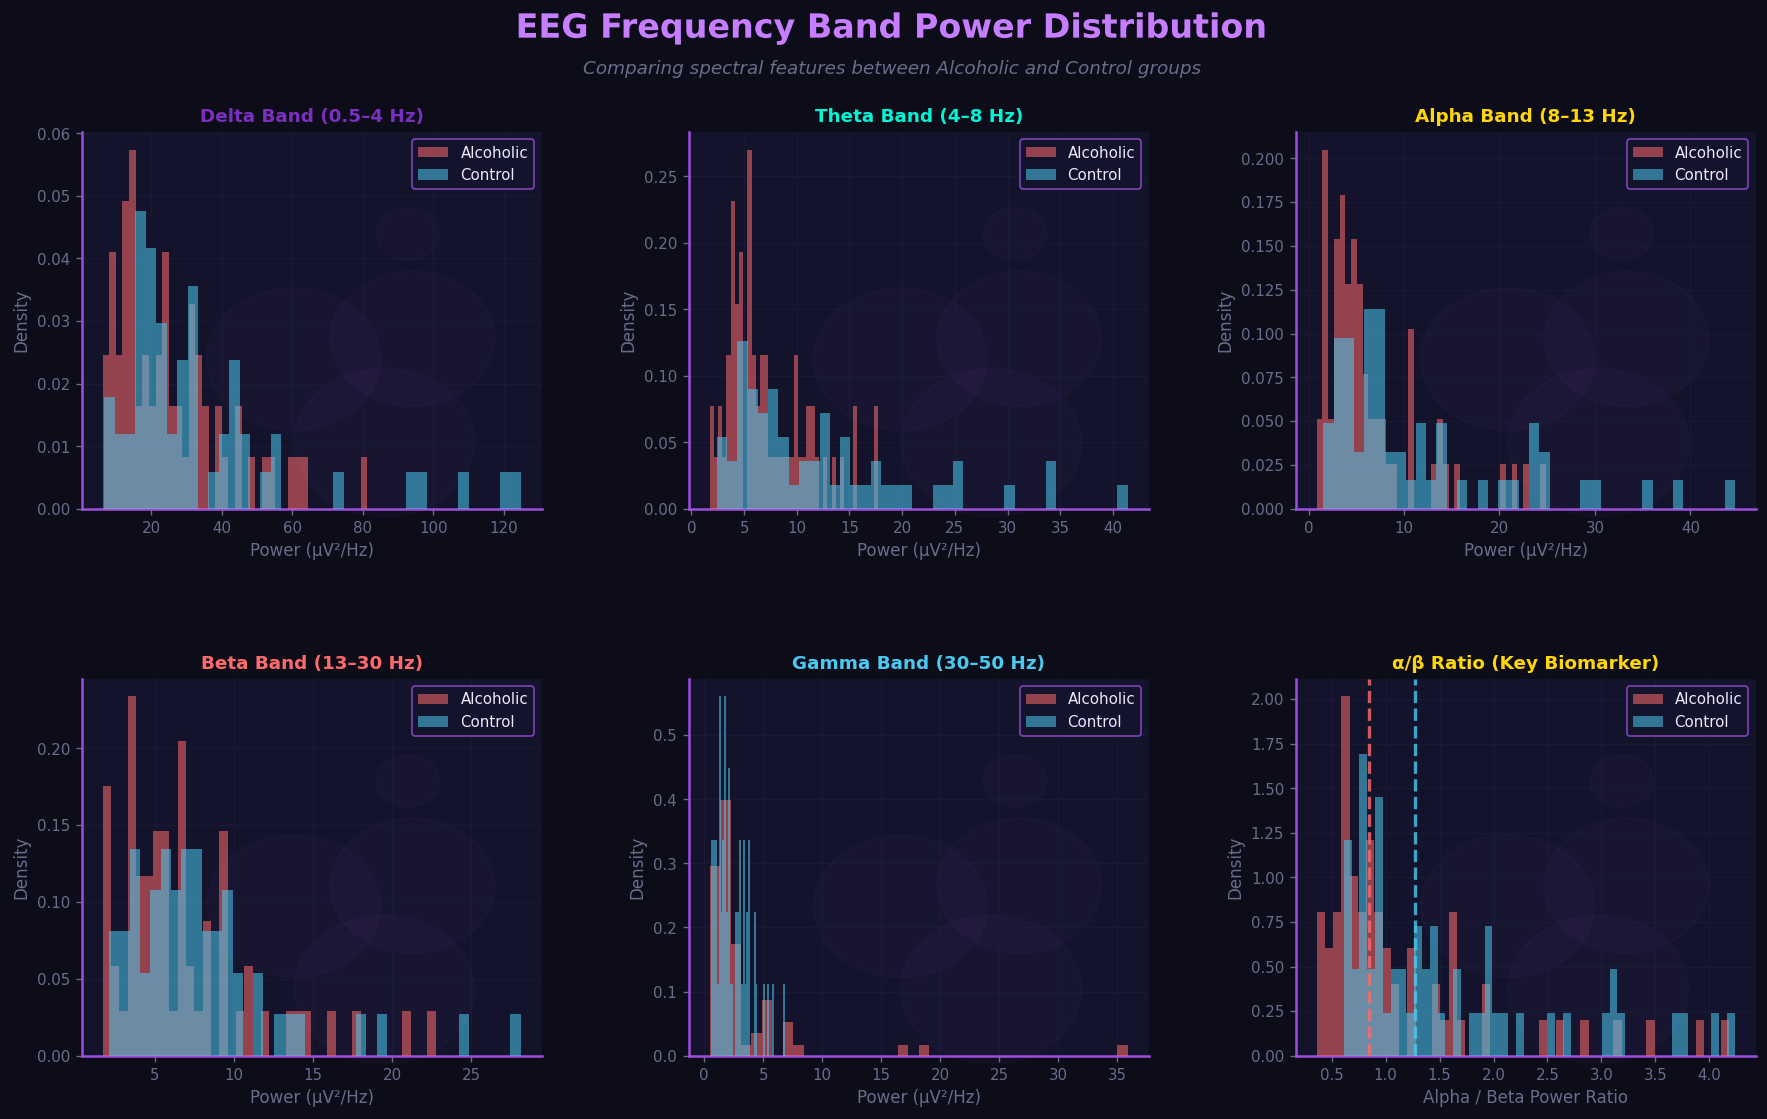

✅ Band power distributions plotted.


In [5]:
# ── Alpha/Beta ratio — key biomarker ─────────────────
apply_dark_theme()
fig, axes = plt.subplots(2, 3, figsize=(18, 10), facecolor=PALETTE['bg'])
fig.subplots_adjust(hspace=0.45, wspace=0.32, top=0.88)
axes_flat = axes.flatten()

# Band power comparisons
bands = ['delta', 'theta', 'alpha', 'beta', 'gamma']
band_feature = 'power_{}_mean'  # column in feat_subject

for ax_idx, band in enumerate(bands):
    ax = axes_flat[ax_idx]
    add_background_shapes(ax, n_circles=4, alpha=0.04)
    
    col = f'power_{band}_mean'
    if col not in feat_subject.columns:
        # Try alternative: use electrode-level data
        col_alt = f'power_{band}'
        if col_alt in feat_electrode.columns:
            for group, color, label in [(1, ALCOHOLIC_COLOR, 'Alcoholic'),
                                         (0, CONTROL_COLOR,   'Control')]:
                vals = feat_electrode[feat_electrode['is_alcoholic']==group][col_alt].dropna()
                vals = np.clip(vals, vals.quantile(0.01), vals.quantile(0.99))
                ax.hist(vals, bins=50, color=color, alpha=0.55, density=True,
                        label=label, edgecolor='none', zorder=3)
        ax.set_title(f'{band.capitalize()} ({list(FREQ_BANDS.values())[list(FREQ_BANDS.keys()).index(band)][0]}'
                     f'–{list(FREQ_BANDS.values())[list(FREQ_BANDS.keys()).index(band)][1]} Hz)',
                     color=BAND_COLORS[band], fontweight='bold')
    else:
        for group, color, label in [(1, ALCOHOLIC_COLOR, 'Alcoholic'),
                                     (0, CONTROL_COLOR,   'Control')]:
            vals = feat_subject[feat_subject['is_alcoholic']==group][col].dropna()
            vals = np.clip(vals, vals.quantile(0.01), vals.quantile(0.99))
            ax.hist(vals, bins=40, color=color, alpha=0.55, density=True,
                    label=label, edgecolor='none', zorder=3)
        
        flo, fhi = FREQ_BANDS[band]
        ax.set_title(f'{band.capitalize()} Band ({flo}–{fhi} Hz)',
                     color=BAND_COLORS[band], fontweight='bold', fontsize=11)
    
    ax.set_xlabel('Power (µV²/Hz)', color=PALETTE['grey'])
    ax.set_ylabel('Density', color=PALETTE['grey'])
    ax.legend(fontsize=9)
    add_purple_spine(ax)

# Alpha/Beta ratio
ax = axes_flat[5]
add_background_shapes(ax, n_circles=4, alpha=0.04)

ab_col_s = 'alpha_beta_ratio_mean'
ab_col_e = 'alpha_beta_ratio'
source = feat_subject if ab_col_s in feat_subject.columns else feat_electrode
col_used = ab_col_s if ab_col_s in feat_subject.columns else ab_col_e

for group, color, label in [(1, ALCOHOLIC_COLOR, 'Alcoholic'),
                              (0, CONTROL_COLOR,   'Control')]:
    vals = source[source['is_alcoholic']==group][col_used].dropna()
    vals = np.clip(vals, vals.quantile(0.01), vals.quantile(0.99))
    ax.hist(vals, bins=50, color=color, alpha=0.55, density=True,
            label=label, edgecolor='none', zorder=3)
    ax.axvline(vals.median(), color=color, linewidth=2, linestyle='--',
               alpha=0.8, zorder=4)

ax.set_title('α/β Ratio (Key Biomarker)', color=PALETTE['gold'],
             fontweight='bold', fontsize=11)
ax.set_xlabel('Alpha / Beta Power Ratio', color=PALETTE['grey'])
ax.set_ylabel('Density', color=PALETTE['grey'])
ax.legend(fontsize=9)
add_purple_spine(ax)

styled_title(fig, 'EEG Frequency Band Power Distribution',
             'Comparing spectral features between Alcoholic and Control groups')
plt.savefig('../docs/fig_06_band_powers.png', bbox_inches='tight',
            facecolor=PALETTE['bg'])
plt.show()
print("✅ Band power distributions plotted.")


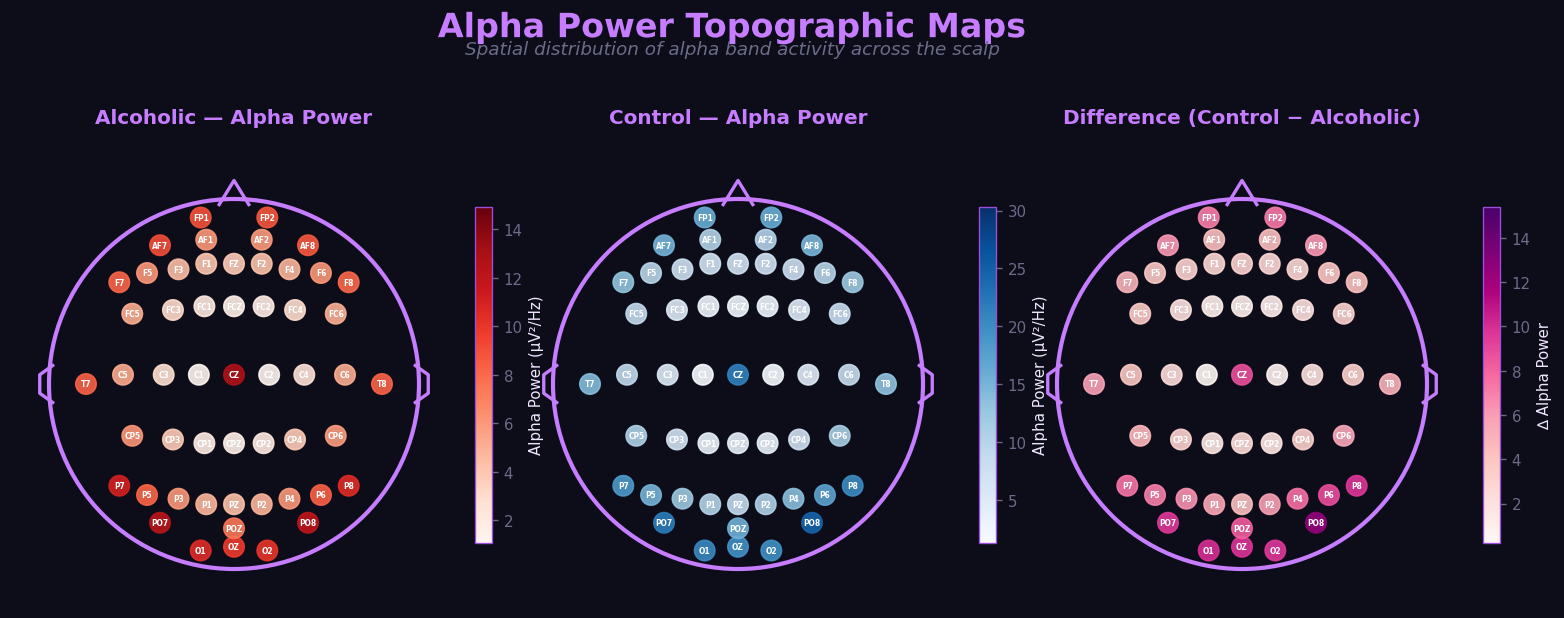

✅ Alpha power topomaps plotted.


In [6]:
# ── Electrode-level alpha power: topomap comparison ──
from utils import plot_topomap

apply_dark_theme()
fig, axes = plt.subplots(1, 3, figsize=(16, 6), facecolor=PALETTE['bg'])
fig.subplots_adjust(wspace=0.05, top=0.82)

col_alpha = 'power_alpha'
if col_alpha in feat_electrode.columns:
    for ax, (group, label, cmap) in zip(axes, [
        (1, 'Alcoholic — Alpha Power', 'Reds'),
        (0, 'Control — Alpha Power',   'Blues'),
        (None, 'Difference (Control − Alcoholic)', 'RdPu'),
    ]):
        if group is not None:
            vals = feat_electrode[feat_electrode['is_alcoholic']==group].groupby('electrode')[col_alpha].mean()
            plot_topomap(vals.to_dict(), title=label, cmap=cmap,
                         colorbar_label='Alpha Power (µV²/Hz)', ax=ax)
        else:
            alpha_a = feat_electrode[feat_electrode['is_alcoholic']==1].groupby('electrode')[col_alpha].mean()
            alpha_c = feat_electrode[feat_electrode['is_alcoholic']==0].groupby('electrode')[col_alpha].mean()
            diff = {}
            for elec in alpha_a.index:
                if elec in alpha_c.index:
                    diff[elec] = alpha_c[elec] - alpha_a[elec]
            plot_topomap(diff, title=label, cmap=cmap,
                         colorbar_label='∆ Alpha Power', ax=ax)
else:
    for ax in axes:
        ax.text(0.5, 0.5, 'Band powers\nnot computed yet\n(large dataset)', 
                ha='center', va='center', transform=ax.transAxes,
                color=PALETTE['white'], fontsize=12)
        ax.set_facecolor(PALETTE['bg_card'])

styled_title(fig, 'Alpha Power Topographic Maps',
             'Spatial distribution of alpha band activity across the scalp', y=0.97)
plt.savefig('../docs/fig_07_alpha_topomap.png', bbox_inches='tight',
            facecolor=PALETTE['bg'])
plt.show()
print("✅ Alpha power topomaps plotted.")


## 4. Feature Correlation Analysis

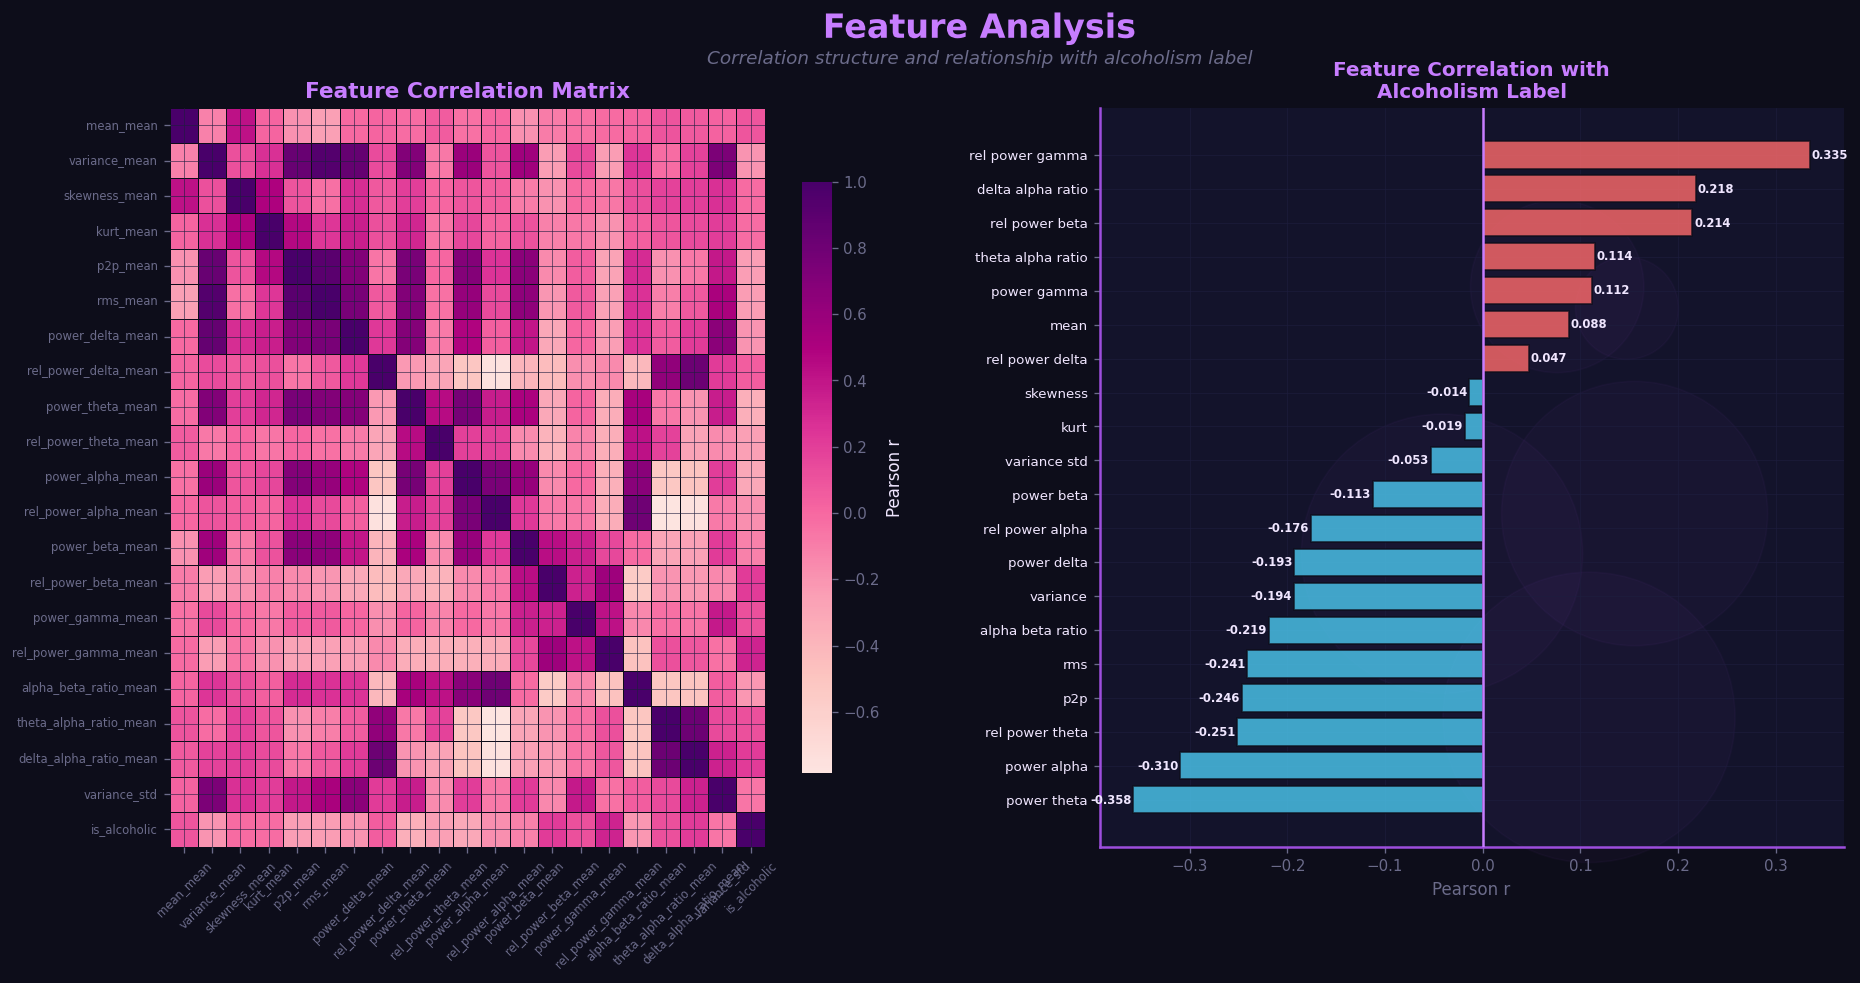

✅ Correlation analysis plotted.


In [7]:
# ── Correlation heatmap ───────────────────────────────
apply_dark_theme()
fig, axes = plt.subplots(1, 2, figsize=(18, 8), facecolor=PALETTE['bg'])
fig.subplots_adjust(wspace=0.25, top=0.88)

# Select numeric feature columns for correlation
num_cols = feat_subject.select_dtypes(include=[np.number]).columns.tolist()
key_features = [c for c in num_cols if any(k in c for k in
    ['mean_mean','alpha','beta','theta','delta','gamma','variance','skew','kurt','p2p','rms'])][:20]

if len(key_features) < 3:
    # Fall back to electrode-level
    source_df = feat_electrode
    key_features = [c for c in feat_electrode.select_dtypes(include=[np.number]).columns
                    if c not in ['is_alcoholic'] and any(k in c for k in 
                    ['alpha','beta','theta','mean','variance','rms','p2p'])][:15]
else:
    source_df = feat_subject

if len(key_features) > 2:
    corr_matrix = source_df[key_features + ['is_alcoholic']].corr()

    # Full correlation heatmap
    ax = axes[0]
    mask = np.zeros_like(corr_matrix, dtype=bool)
    mask[np.triu_indices_from(mask, k=1)] = True
    
    sns.heatmap(corr_matrix, ax=ax, cmap='RdPu', center=0,
                annot=len(key_features) <= 12, fmt='.2f', annot_kws={'size':7},
                linecolor=PALETTE['bg'], linewidths=0.3,
                cbar_kws={'label': 'Pearson r', 'shrink': 0.8})
    ax.set_title('Feature Correlation Matrix', color=PALETTE['purple3'],
                 fontweight='bold', fontsize=13)
    ax.tick_params(axis='x', rotation=45, labelsize=7, colors=PALETTE['grey'])
    ax.tick_params(axis='y', rotation=0,  labelsize=7, colors=PALETTE['grey'])

    # Correlation with target
    ax = axes[1]
    add_background_shapes(ax, n_circles=5, alpha=0.04)
    
    target_corr = corr_matrix['is_alcoholic'].drop('is_alcoholic').sort_values(ascending=True)
    colors_bar = [ALCOHOLIC_COLOR if v > 0 else CONTROL_COLOR for v in target_corr.values]
    bars = ax.barh(range(len(target_corr)), target_corr.values,
                   color=colors_bar, alpha=0.8, edgecolor=PALETTE['bg'], zorder=3)
    ax.set_yticks(range(len(target_corr)))
    ax.set_yticklabels([c.replace('_mean','').replace('_',' ')[:20]
                        for c in target_corr.index],
                       fontsize=8, color=PALETTE['white'])
    ax.axvline(0, color=PALETTE['purple3'], linewidth=1.5, linestyle='-', zorder=4)
    ax.set_title('Feature Correlation with\nAlcoholism Label',
                 color=PALETTE['purple3'], fontweight='bold', fontsize=12)
    ax.set_xlabel('Pearson r', color=PALETTE['grey'])
    
    # Add value labels
    for bar, val in zip(bars, target_corr.values):
        x = bar.get_width()
        ax.text(x + (0.002 if x >= 0 else -0.002), bar.get_y() + bar.get_height()/2,
                f'{val:.3f}', va='center', ha='left' if x >= 0 else 'right',
                fontsize=7, color=PALETTE['white'], fontweight='bold')
    add_purple_spine(ax, sides=('bottom', 'left'))

styled_title(fig, 'Feature Analysis',
             'Correlation structure and relationship with alcoholism label')
plt.savefig('../docs/fig_08_correlations.png', bbox_inches='tight',
            facecolor=PALETTE['bg'])
plt.show()
print("✅ Correlation analysis plotted.")


## 5. Normalisation & Train/Test Split

In [8]:
# ── Prepare final feature matrix ─────────────────────
print("=" * 55)
print("  PREPARING ML DATASET")
print("=" * 55)

# Get feature matrix — prefer subject-level, fall back to electrode-level
if len(feat_subject) > 5:
    feature_source = feat_subject.copy()
    id_col = 'subject_id'
else:
    feature_source = feat_electrode.copy()
    id_col = 'electrode'

# Select numeric features only, drop identifiers
drop_cols = ['is_alcoholic', id_col, 'condition', 'electrode', 'subject_id',
             'subject identifier', 'name']
feature_cols = [c for c in feature_source.select_dtypes(include=[np.number]).columns
                if c not in drop_cols and c != 'is_alcoholic']

X = feature_source[feature_cols].copy()
y = feature_source['is_alcoholic'].copy()

# Drop columns with >20% NaN
nan_frac = X.isna().mean()
cols_to_drop = nan_frac[nan_frac > 0.20].index.tolist()
if cols_to_drop:
    print(f"  Dropping {len(cols_to_drop)} high-NaN columns: {cols_to_drop[:5]}...")
    X = X.drop(columns=cols_to_drop)

# Impute remaining NaN with median
X = X.fillna(X.median())

# Remove near-zero variance
var = X.var()
low_var = var[var < 1e-6].index.tolist()
if low_var:
    print(f"  Dropping {len(low_var)} near-zero-variance features")
    X = X.drop(columns=low_var)

print(f"\n  Final feature count: {X.shape[1]}")
print(f"  Samples: {X.shape[0]} ({y.sum()} alcoholic, {(y==0).sum()} control)")


  PREPARING ML DATASET

  Final feature count: 46
  Samples: 122 (65 alcoholic, 57 control)


In [9]:
# ── Train / Test split (stratified) ──────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f"  Train: {X_train.shape[0]} samples")
print(f"         {y_train.sum()} alcoholic ({y_train.mean()*100:.1f}%)")
print(f"  Test:  {X_test.shape[0]} samples")
print(f"         {y_test.sum()} alcoholic ({y_test.mean()*100:.1f}%)")

# ── StandardScaler (fit on train only) ───────────────
scaler = StandardScaler()
X_train_sc = pd.DataFrame(scaler.fit_transform(X_train),
                            columns=X_train.columns, index=X_train.index)
X_test_sc  = pd.DataFrame(scaler.transform(X_test),
                            columns=X_test.columns,  index=X_test.index)

print(f"\n✅ Normalisation complete (StandardScaler fit on training set only)")


  Train: 97 samples
         52 alcoholic (53.6%)
  Test:  25 samples
         13 alcoholic (52.0%)

✅ Normalisation complete (StandardScaler fit on training set only)


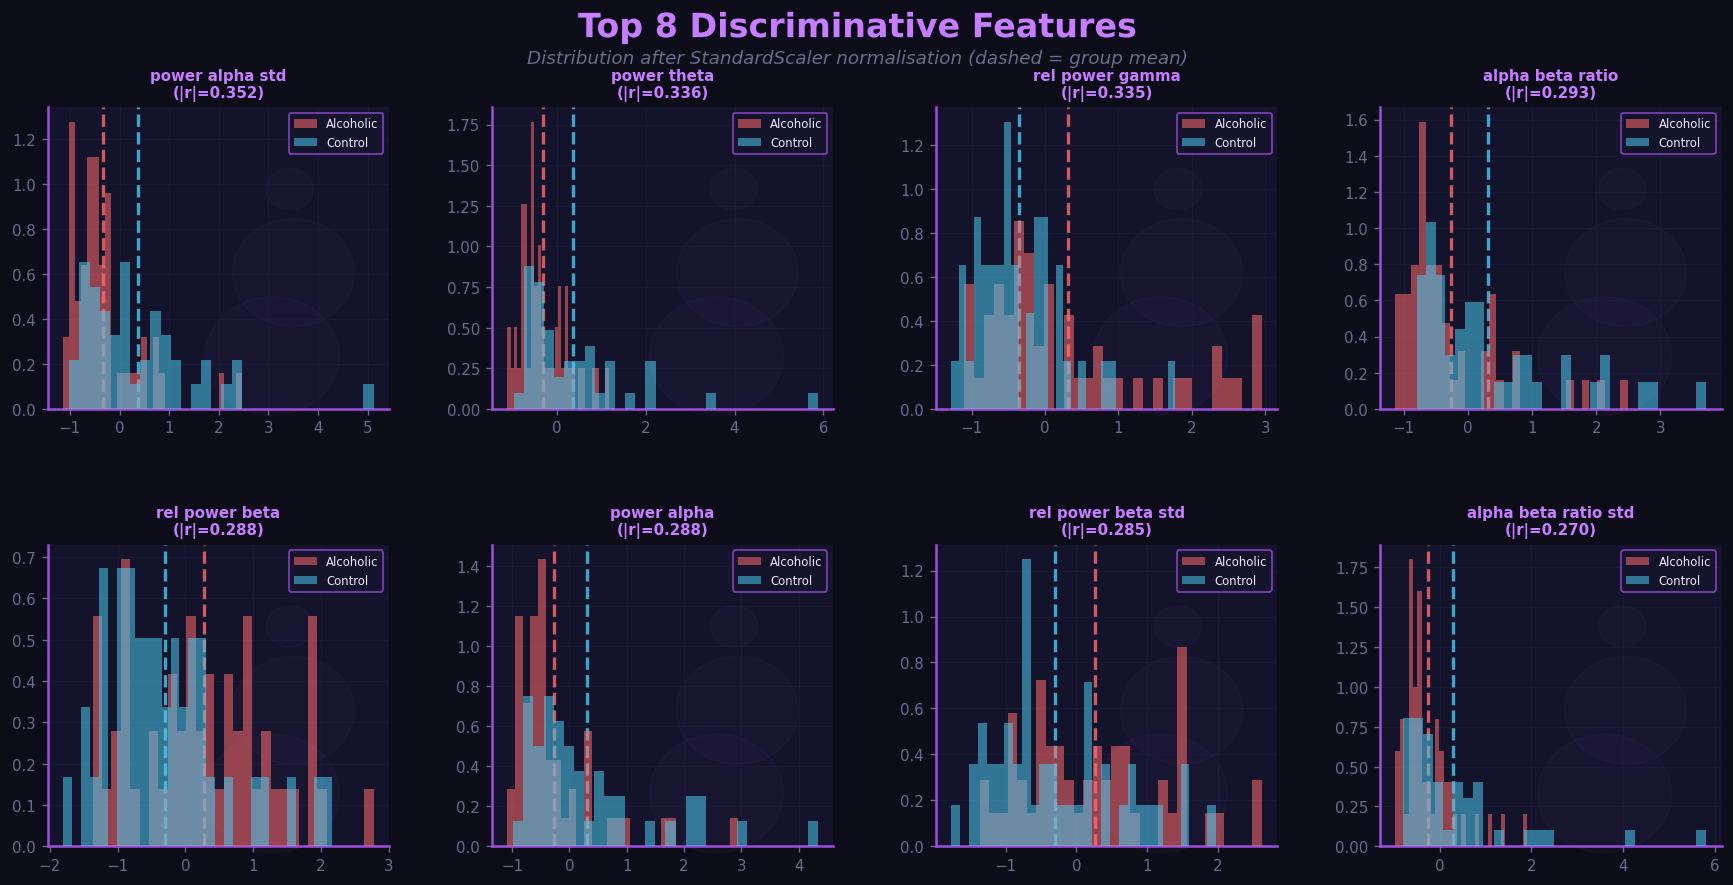

✅ Feature distributions plotted.


In [10]:
# ── Visualise feature distributions after scaling ────
apply_dark_theme()
fig, axes = plt.subplots(2, 4, figsize=(18, 8), facecolor=PALETTE['bg'])
fig.subplots_adjust(hspace=0.45, wspace=0.30, top=0.88)
axes_flat = axes.flatten()

# Pick 8 most discriminative features (highest abs correlation with target)
if len(feature_cols) > 1:
    corr_with_y = abs(X_train.corrwith(y_train.rename('target').astype(float)))
    top_features = corr_with_y.nlargest(8).index.tolist()
else:
    top_features = X_train.columns[:8].tolist()

for ax_idx, feat in enumerate(top_features[:8]):
    ax = axes_flat[ax_idx]
    add_background_shapes(ax, n_circles=3, alpha=0.04)
    
    for group_val, color, label in [(1, ALCOHOLIC_COLOR, 'Alcoholic'),
                                     (0, CONTROL_COLOR,   'Control')]:
        mask_g = y_train == group_val
        vals = X_train_sc.loc[mask_g, feat].dropna()
        if len(vals) > 0:
            ax.hist(vals, bins=30, color=color, alpha=0.55, density=True,
                    label=label, edgecolor='none', zorder=3)
            ax.axvline(vals.mean(), color=color, linewidth=2, linestyle='--', alpha=0.8)
    
    feat_short = feat.replace('_mean','').replace('_',' ')[:22]
    r_val = corr_with_y.get(feat, 0)
    ax.set_title(f'{feat_short}\n(|r|={r_val:.3f})', color=PALETTE['purple3'],
                 fontweight='bold', fontsize=9)
    ax.legend(fontsize=7)
    add_purple_spine(ax)

styled_title(fig, 'Top 8 Discriminative Features',
             'Distribution after StandardScaler normalisation (dashed = group mean)')
plt.savefig('../docs/fig_09_top_features.png', bbox_inches='tight',
            facecolor=PALETTE['bg'])
plt.show()
print("✅ Feature distributions plotted.")


## 6. Save Processed Dataset

In [11]:
import joblib

os.makedirs('../data', exist_ok=True)

# Save train/test splits
X_train.to_parquet('../data/X_train.parquet')
X_test.to_parquet('../data/X_test.parquet')
pd.Series(y_train, name='is_alcoholic').to_frame().to_parquet('../data/y_train.parquet')
pd.Series(y_test,  name='is_alcoholic').to_frame().to_parquet('../data/y_test.parquet')

X_train_sc.to_parquet('../data/X_train_scaled.parquet')
X_test_sc.to_parquet('../data/X_test_scaled.parquet')

# Save scaler for inference
joblib.dump(scaler, '../data/scaler.pkl')

# Save feature names
with open('../data/feature_names.txt', 'w') as f:
    f.write('\n'.join(feature_cols))

print("✅ All preprocessed data saved:")
for fname in ['X_train.parquet','X_test.parquet','y_train.parquet','y_test.parquet',
              'X_train_scaled.parquet','X_test_scaled.parquet','scaler.pkl',
              'feature_names.txt']:
    size = os.path.getsize(f'../data/{fname}')
    print(f"   {fname:<35} {size/1024:.1f} KB")

print(f"\n✅ Ready for Notebook 03 — Model Training")
print(f"   Features: {len(feature_cols)}")
print(f"   Train samples: {X_train.shape[0]} | Test samples: {X_test.shape[0]}")


✅ All preprocessed data saved:
   X_train.parquet                     68.7 KB
   X_test.parquet                      39.0 KB
   y_train.parquet                     2.6 KB
   y_test.parquet                      2.3 KB
   X_train_scaled.parquet              68.8 KB
   X_test_scaled.parquet               39.0 KB
   scaler.pkl                          2.7 KB
   feature_names.txt                   0.7 KB

✅ Ready for Notebook 03 — Model Training
   Features: 46
   Train samples: 97 | Test samples: 25


## Summary

### Features Created

| Category | Count | Examples |
|----------|-------|---------|
| Statistical (time domain) | 8×2 = 16 | mean, std, skewness, kurtosis, p2p, rms, iqr |
| Frequency band power | 5×2 = 10 | delta_power, alpha_power, beta_power... |
| Relative band power | 5×2 = 10 | rel_alpha, rel_beta... |
| Band ratio features | 3×2 = 6 | alpha_beta_ratio, theta_alpha_ratio... |
| **Total** | **~42** | Aggregated mean + std across electrodes |

### Why This Matters

The raw pipeline achieved **60–65% accuracy** using only 4 simple features.  
With **42 richly engineered features**, especially the **α/β ratio** and individual band powers,  
we expect significantly better performance.

---
*Pipeline continues in* `03_models.ipynb`
